In [1]:
!pip install folium geopandas scikit-learn seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='flare')
plt.rcParams['figure.dpi'] = 120
print('✅ All libraries loaded!')

✅ All libraries loaded!


In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Saving dataset for my project.csv to dataset for my project (1).csv
✅ Loaded: 1,048,575 rows × 14 columns


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight
0,68.61322,57.96839,335.86,0.39,0.44,01-05-2026,11,N20,VIIRS,n,2.0NRT,270.93,7.73,D
1,66.31300,14.17053,300.20,0.42,0.61,01-05-2026,13,N20,VIIRS,n,2.0NRT,274.23,1.16,N
2,56.99064,50.48178,306.55,0.39,0.59,01-05-2026,13,N20,VIIRS,n,2.0NRT,270.71,0.73,N
3,54.84966,56.11295,303.16,0.72,0.76,01-05-2026,13,N20,VIIRS,n,2.0NRT,275.60,2.95,N
4,56.40166,55.56104,299.47,0.59,0.70,01-05-2026,13,N20,VIIRS,n,2.0NRT,267.32,1.52,N


In [3]:
print('Shape:', df.shape)
print('\nDtypes:\n', df.dtypes)
print('\nMissing Values:\n', df.isnull().sum())
print('\nStats:')
df[['brightness', 'frp', 'bright_t31']].describe().round(2)

Shape: (1048575, 14)

Dtypes:
 latitude      float64
longitude     float64
brightness    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version        object
bright_t31    float64
frp           float64
daynight       object
dtype: object

Missing Values:
 latitude      0
longitude     0
brightness    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_t31    0
frp           0
daynight      0
dtype: int64

Stats:


,brightness,frp,bright_t31
count,1048575.00,1048575.00,1048575.00
mean,333.34,8.10,297.30
std,16.73,14.82,9.90
min,207.93,0.00,231.61
25%,328.77,2.51,291.45
50%,335.69,4.71,298.09
75%,343.15,8.50,303.36
max,367.00,1174.60,379.70


In [4]:
df['acq_date'] = pd.to_datetime(df['acq_date'], dayfirst=True)

conf_map = {'h': 'High', 'n': 'Nominal', 'l': 'Low'}
df['confidence_label'] = df['confidence'].map(conf_map)

df['intensity_score'] = (
    (df['brightness'] - df['brightness'].min()) / (df['brightness'].max() - df['brightness'].min()) * 0.5 +
    (df['frp'] - df['frp'].min()) / (df['frp'].max() - df['frp'].min()) * 0.5
).round(4)

df_filtered = df[df['confidence'].isin(['h', 'n'])].copy()

print(f'Original: {len(df):,} rows')
print(f'Filtered (high + nominal): {len(df_filtered):,} rows')
print(f'Date range: {df["acq_date"].min().date()} → {df["acq_date"].max().date()}')
print('\nConfidence Distribution:')
print(df['confidence_label'].value_counts())

Original: 1,048,575 rows
Filtered (high + nominal): 946,674 rows
Date range: 2026-05-01 → 2026-06-05

Confidence Distribution:
confidence_label
Nominal    904343
Low        101901
High        42331
Name: count, dtype: int64


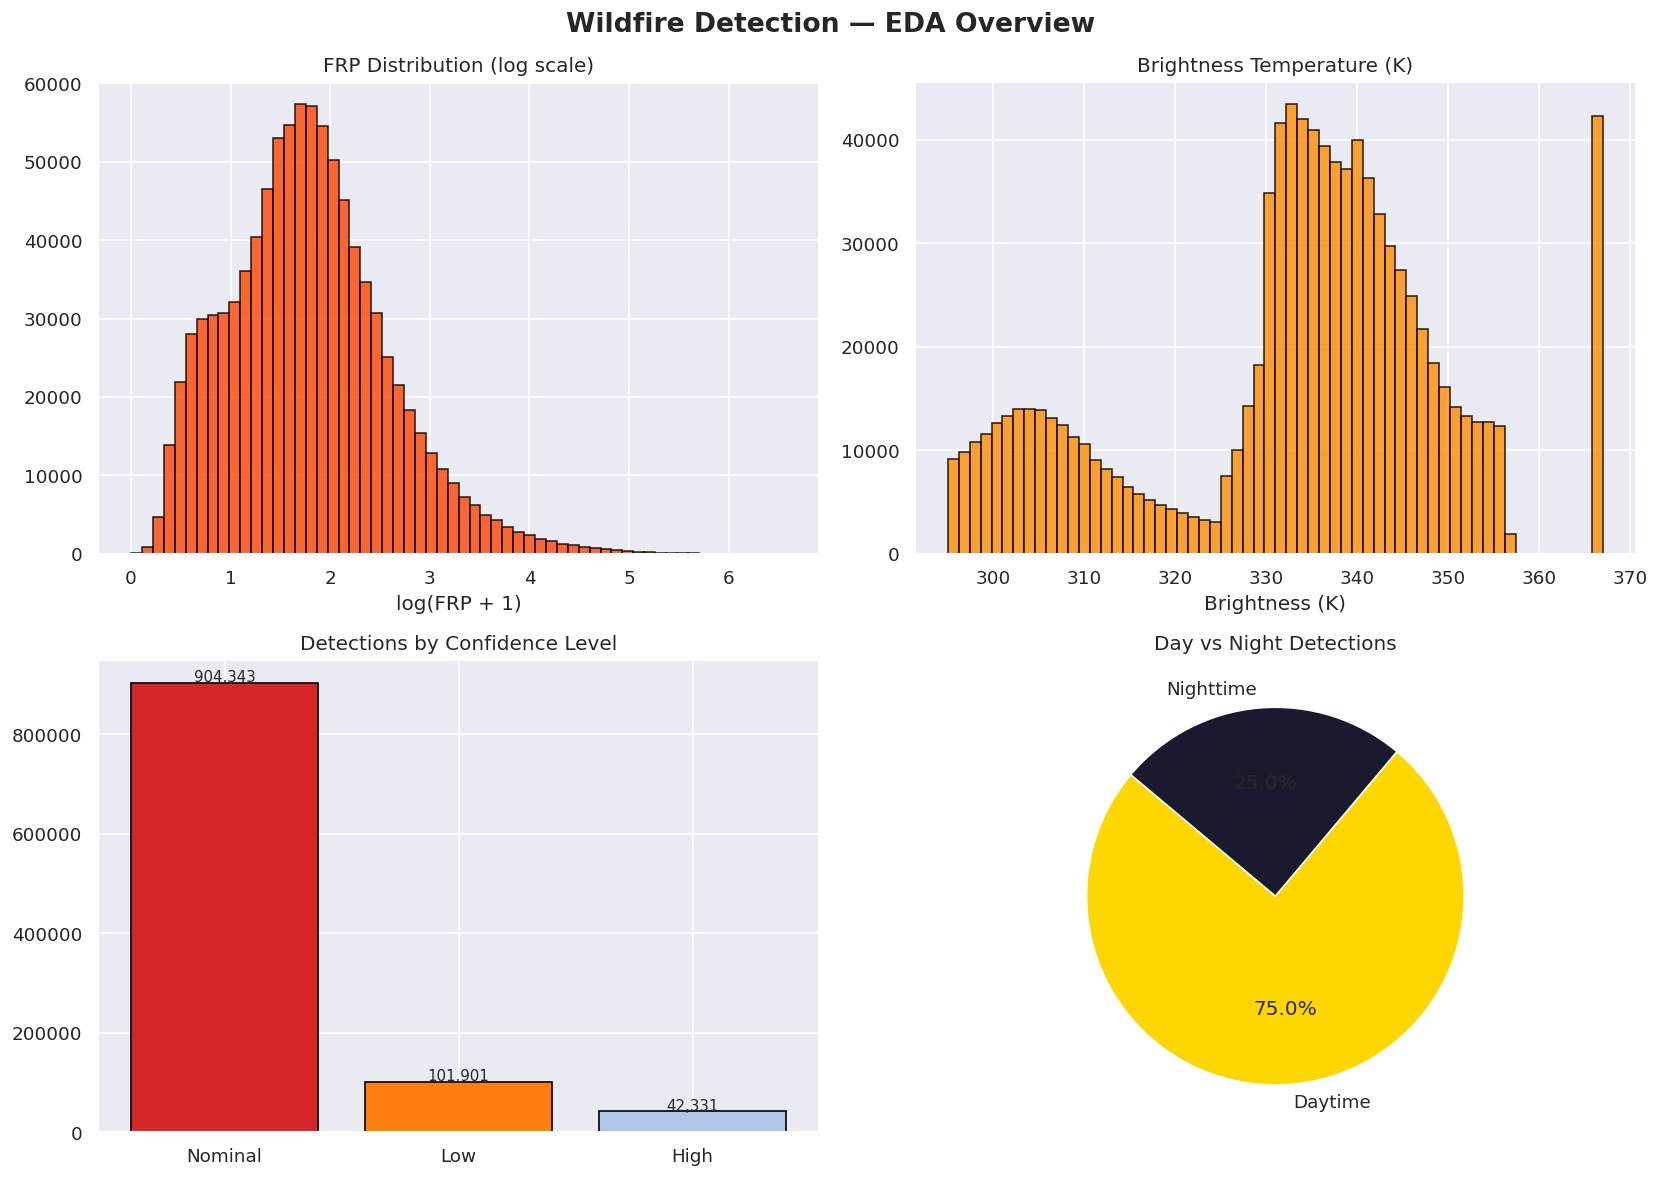

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Wildfire Detection — EDA Overview', fontsize=16, fontweight='bold')

axes[0,0].hist(np.log1p(df_filtered['frp']), bins=60, color='orangered', edgecolor='black', alpha=0.8)
axes[0,0].set_title('FRP Distribution (log scale)')
axes[0,0].set_xlabel('log(FRP + 1)')

axes[0,1].hist(df_filtered['brightness'], bins=60, color='darkorange', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Brightness Temperature (K)')
axes[0,1].set_xlabel('Brightness (K)')

conf_counts = df['confidence_label'].value_counts()
axes[1,0].bar(conf_counts.index, conf_counts.values, color=['#d62728','#ff7f0e','#aec7e8'], edgecolor='black')
axes[1,0].set_title('Detections by Confidence Level')
for i, v in enumerate(conf_counts.values):
    axes[1,0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

dn_counts = df['daynight'].value_counts()
dn_labels = ['Daytime' if x == 'D' else 'Nighttime' for x in dn_counts.index]
axes[1,1].pie(dn_counts.values, labels=dn_labels, autopct='%1.1f%%',
              colors=['#FFD700','#1a1a2e'], startangle=140)
axes[1,1].set_title('Day vs Night Detections')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

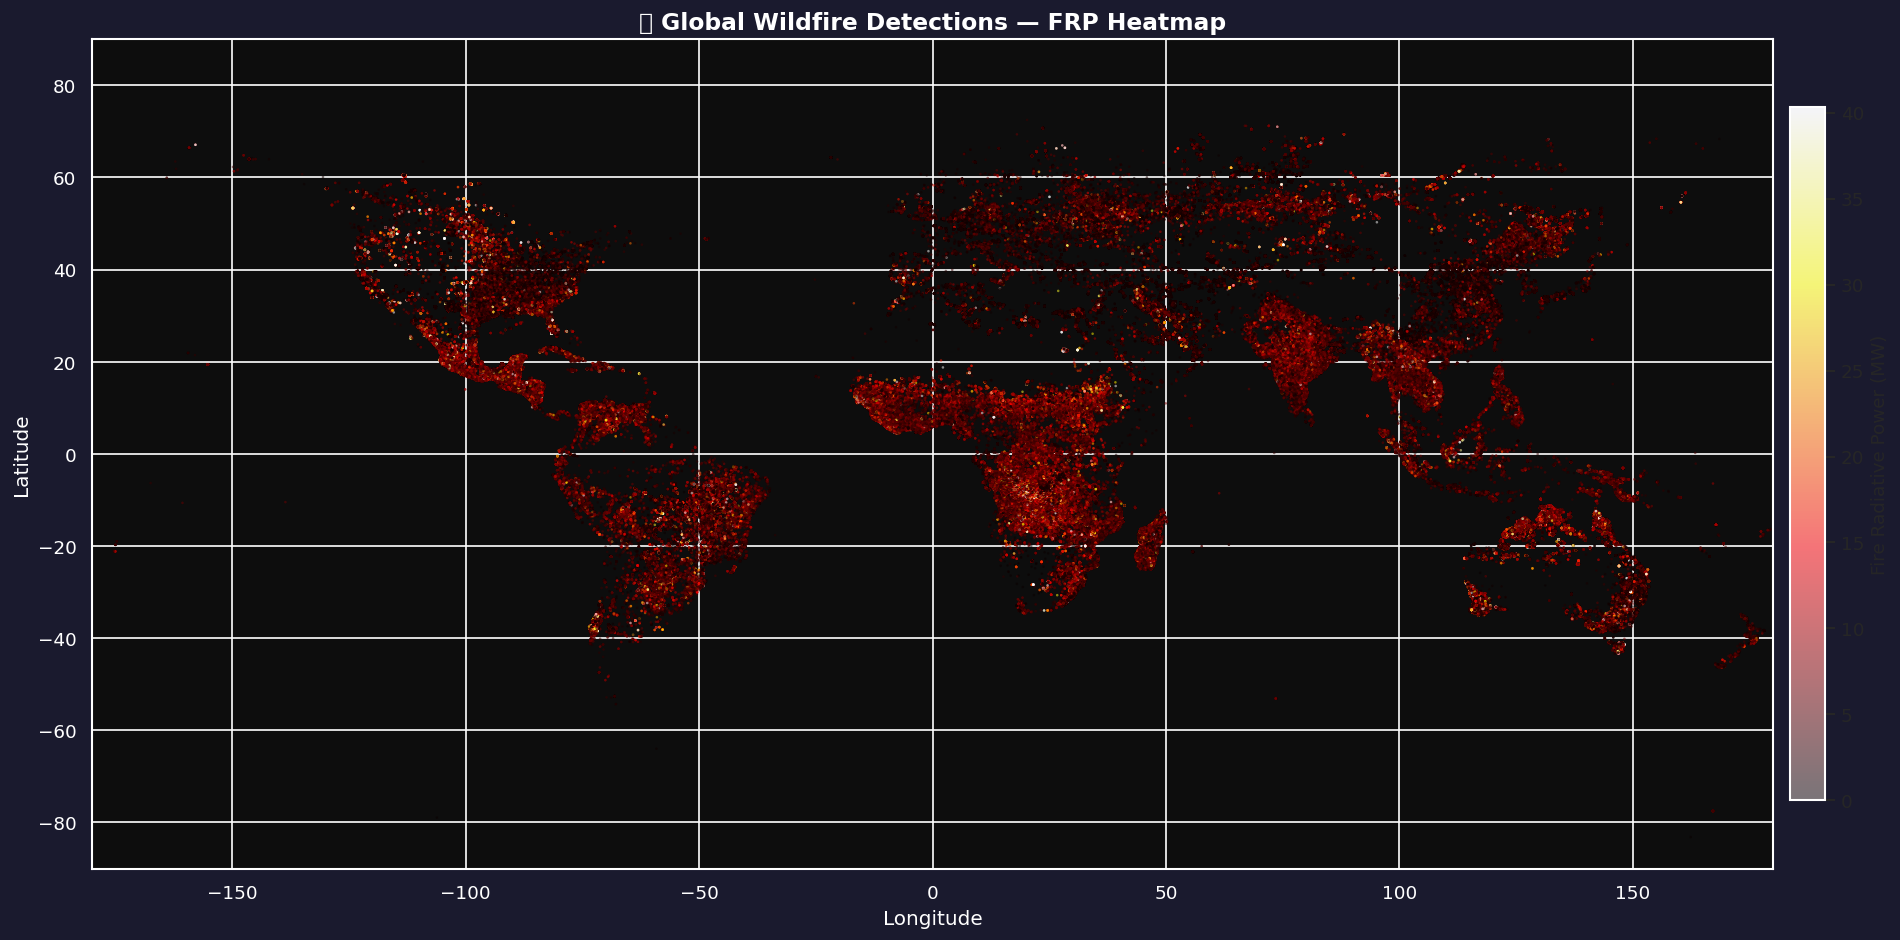

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))

scatter = ax.scatter(
    df_filtered['longitude'], df_filtered['latitude'],
    c=df_filtered['frp'],
    cmap='hot', s=0.3, alpha=0.5,
    vmin=0, vmax=df_filtered['frp'].quantile(0.98)
)

cbar = plt.colorbar(scatter, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('Fire Radiative Power (MW)', fontsize=11)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('🌍 Global Wildfire Detections — FRP Heatmap', color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('global_fire_map.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [7]:
df_filtered['lat_bin'] = (df_filtered['latitude'] // 2) * 2
df_filtered['lon_bin'] = (df_filtered['longitude'] // 2) * 2

region_risk = df_filtered.groupby(['lat_bin', 'lon_bin']).agg(
    fire_count=('frp', 'count'),
    avg_frp=('frp', 'mean'),
    max_frp=('frp', 'max'),
    total_frp=('frp', 'sum'),
    avg_brightness=('brightness', 'mean'),
    avg_intensity=('intensity_score', 'mean')
).reset_index()

region_risk['risk_score'] = (
    0.4 * (region_risk['fire_count'] / region_risk['fire_count'].max()) +
    0.35 * (region_risk['total_frp'] / region_risk['total_frp'].max()) +
    0.25 * (region_risk['avg_brightness'] / region_risk['avg_brightness'].max())
).round(4)

def classify_risk(score):
    if score >= 0.6:   return '🔴 Extreme'
    elif score >= 0.3: return '🟠 High'
    elif score >= 0.1: return '🟡 Moderate'
    else:              return '🟢 Low'

region_risk['risk_tier'] = region_risk['risk_score'].apply(classify_risk)

print('=== TOP 20 WILDFIRE-PRONE REGIONS ===')
top20 = region_risk.sort_values('risk_score', ascending=False).head(20)
print(top20[['lat_bin','lon_bin','fire_count','total_frp','avg_frp','risk_score','risk_tier']].to_string(index=False))

print('\n=== RISK TIER SUMMARY ===')
print(region_risk['risk_tier'].value_counts())

=== TOP 20 WILDFIRE-PRONE REGIONS ===
 lat_bin  lon_bin  fire_count  total_frp   avg_frp  risk_score risk_tier
    -8.0     24.0       14479  178943.78 12.358849      0.9149 🔴 Extreme
    10.0    -14.0        9461  221286.19 23.389302      0.8452 🔴 Extreme
    -8.0     22.0       14120  119230.64  8.444096      0.8097 🔴 Extreme
    -6.0     18.0       11288  114451.86 10.139251      0.7247 🔴 Extreme
    -8.0     20.0       11963  102609.37  8.577227      0.7241 🔴 Extreme
   -10.0     22.0       10745  118317.64 11.011414      0.7162 🔴 Extreme
    -6.0     24.0       10545  101836.97  9.657370      0.6841 🔴 Extreme
    -6.0     26.0       10185   93682.30  9.198066      0.6601 🔴 Extreme
    -6.0     16.0        9494   92705.21  9.764610      0.6409 🔴 Extreme
   -16.0    130.0        9704   80543.98  8.300080      0.6242 🔴 Extreme
    -8.0     16.0        8162   99845.07 12.232917      0.6167 🔴 Extreme
   -14.0    130.0        8834   85938.14  9.728112      0.6104 🔴 Extreme
   -10.0     

In [8]:
sample = df_filtered.sample(n=min(50000, len(df_filtered)), random_state=42)

heat_data = list(zip(
    sample['latitude'],
    sample['longitude'],
    sample['frp'].clip(upper=sample['frp'].quantile(0.95))
))

m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB dark_matter')

HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=6, blur=4,
    gradient={0.2: '#ffffb2', 0.5: '#fd8d3c', 0.8: '#f03b20', 1.0: '#bd0026'}
).add_to(m)

top10 = region_risk.sort_values('risk_score', ascending=False).head(10)
for _, row in top10.iterrows():
    folium.CircleMarker(
        location=[row['lat_bin'] + 1, row['lon_bin'] + 1],
        radius=8, color='cyan', fill=True, fill_color='cyan', fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>Risk Score: {row['risk_score']:.3f}</b><br>"
            f"Fire Count: {row['fire_count']:,}<br>"
            f"Avg FRP: {row['avg_frp']:.1f} MW<br>"
            f"Tier: {row['risk_tier']}",
            max_width=200
        )
    ).add_to(m)

m.save('wildfire_heatmap.html')
print('✅ Map saved as wildfire_heatmap.html')
m

✅ Map saved as wildfire_heatmap.html


In [9]:
cluster_sample = df_filtered[df_filtered['confidence'] == 'h'].sample(
    n=min(30000, len(df_filtered[df_filtered['confidence'] == 'h'])),
    random_state=42
).copy()

coords_rad = np.radians(cluster_sample[['latitude', 'longitude']].values)

db = DBSCAN(eps=0.0157, min_samples=10, algorithm='ball_tree', metric='haversine', n_jobs=-1)
labels = db.fit_predict(coords_rad)

cluster_sample['cluster'] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f'Fire zones (clusters) found: {n_clusters}')
print(f'Isolated detections (noise): {n_noise:,}')

cluster_stats = cluster_sample[cluster_sample['cluster'] != -1].groupby('cluster').agg(
    count=('frp', 'count'),
    center_lat=('latitude', 'mean'),
    center_lon=('longitude', 'mean'),
    total_frp=('frp', 'sum'),
    max_frp=('frp', 'max')
).reset_index()

print('\nTop 10 Fire Clusters by Total FRP:')
print(cluster_stats.sort_values('total_frp', ascending=False).head(10).to_string(index=False))

Fire zones (clusters) found: 151
Isolated detections (noise): 2,420

Top 10 Fire Clusters by Total FRP:
 cluster  count  center_lat  center_lon  total_frp  max_frp
       2   8911   -7.766475   22.490162  169482.99   284.06
       6   1643   11.165510  -13.062562   52284.84   318.67
       4   2451  -14.521182  129.962304   45674.18   261.83
       5   1967   17.258664  -89.883214   37028.23   265.51
       0   1147   50.030738  130.849536   31946.16   369.25
      12   1474   20.704841 -103.498978   30039.96   428.61
      43    216   60.361937 -113.179767   12560.77   473.42
       7    839   21.610567   79.168142   12374.79   239.96
       8    742  -19.649635   45.711792    9714.81   112.02
      27    653   31.213119   48.682762    9696.76   137.37


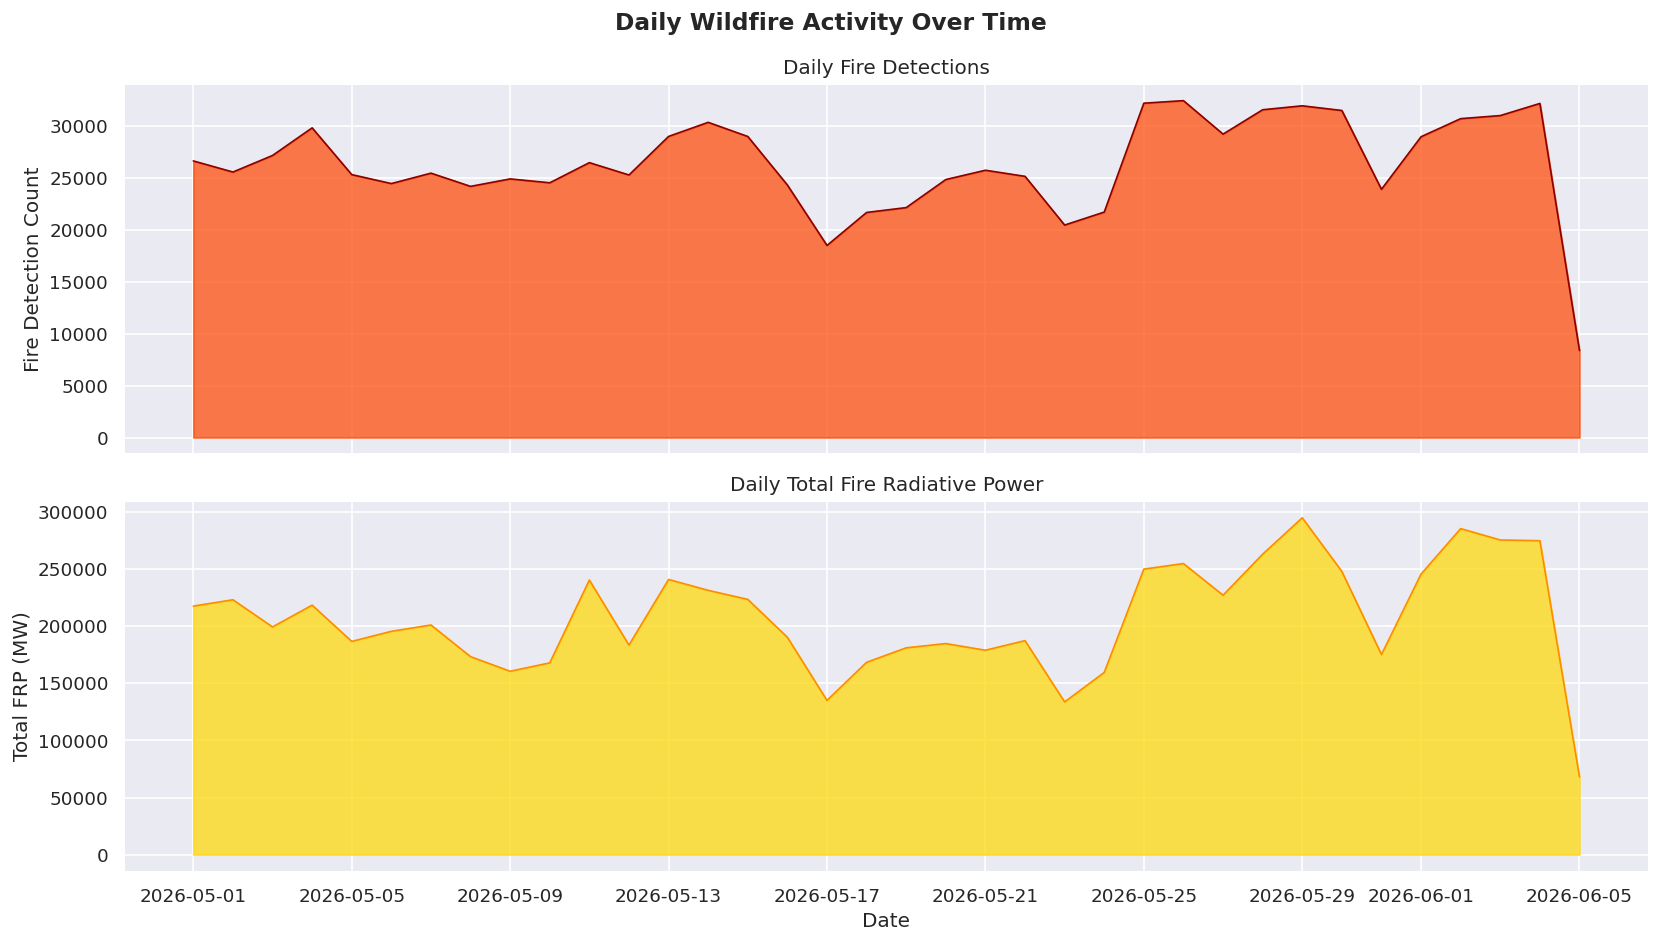

In [10]:
daily = df_filtered.groupby('acq_date').agg(
    fire_count=('frp', 'count'),
    total_frp=('frp', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Daily Wildfire Activity Over Time', fontsize=14, fontweight='bold')

axes[0].fill_between(daily['acq_date'], daily['fire_count'], color='orangered', alpha=0.7)
axes[0].plot(daily['acq_date'], daily['fire_count'], color='darkred', lw=1)
axes[0].set_ylabel('Fire Detection Count')
axes[0].set_title('Daily Fire Detections')

axes[1].fill_between(daily['acq_date'], daily['total_frp'], color='gold', alpha=0.7)
axes[1].plot(daily['acq_date'], daily['total_frp'], color='darkorange', lw=1)
axes[1].set_ylabel('Total FRP (MW)')
axes[1].set_xlabel('Date')
axes[1].set_title('Daily Total Fire Radiative Power')

plt.tight_layout()
plt.savefig('temporal_analysis.png', bbox_inches='tight')
plt.show()

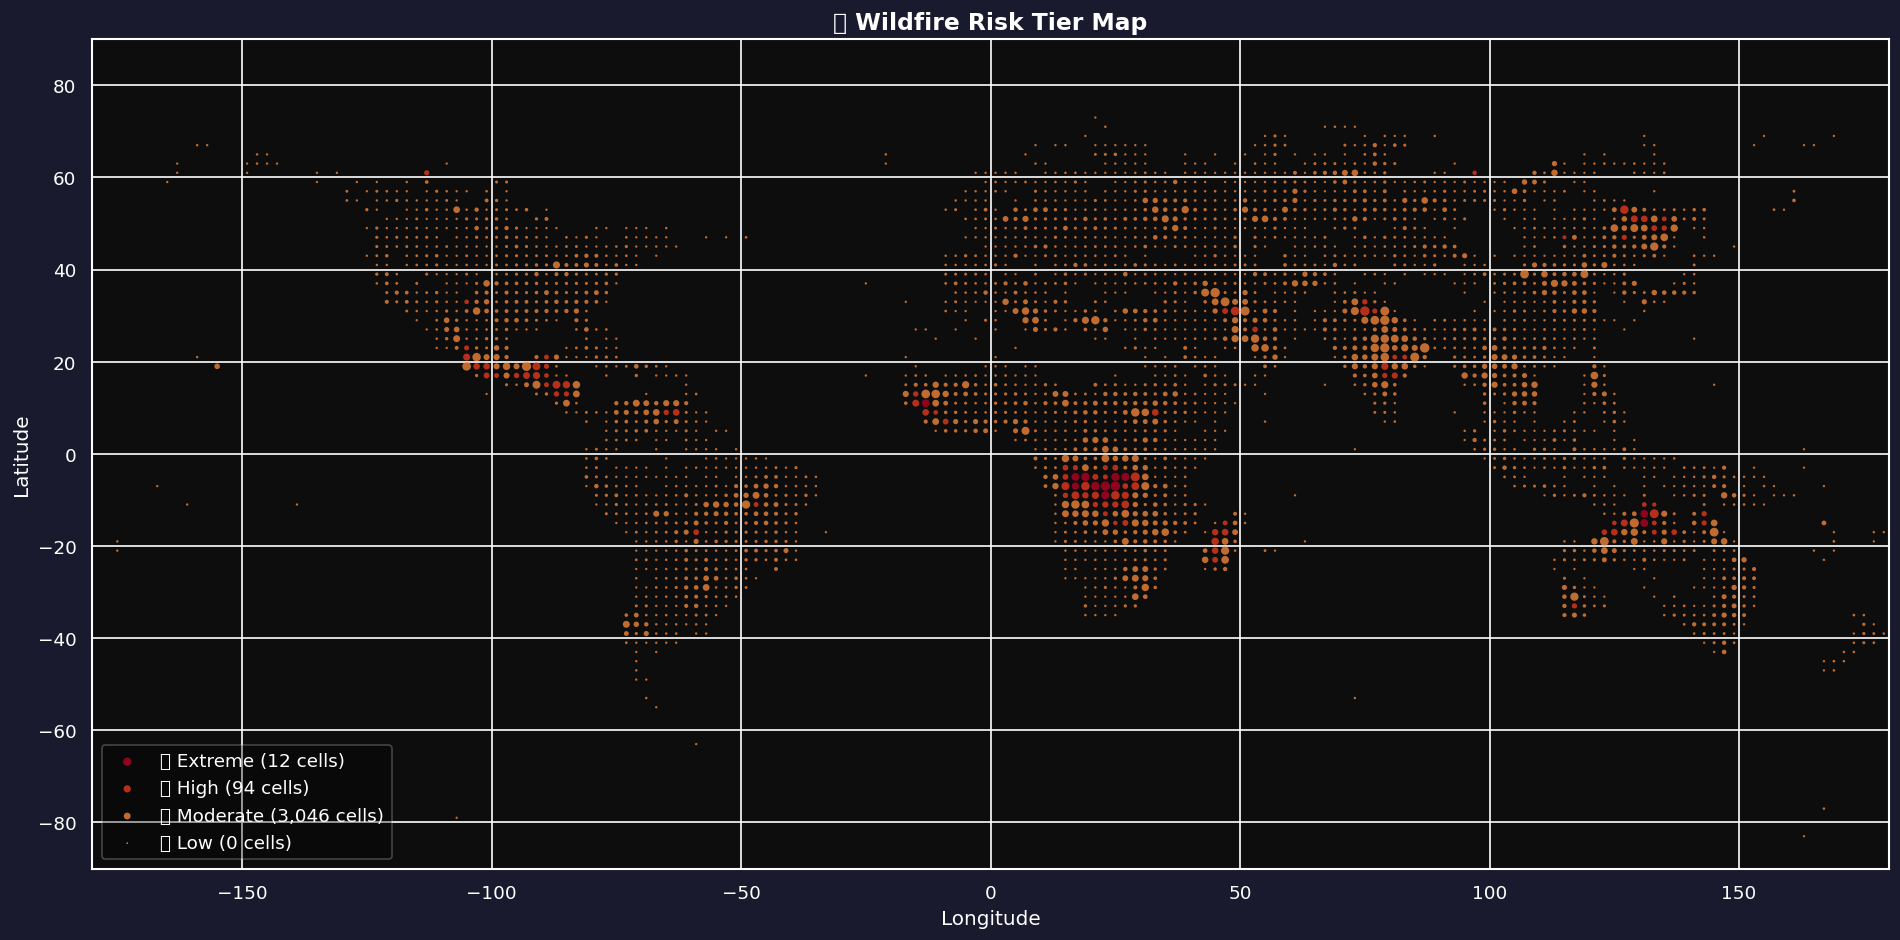

In [11]:
tier_colors = {
    '🔴 Extreme': '#bd0026',
    '🟠 High':    '#f03b20',
    '🟡 Moderate':'#fd8d3c',
    '🟢 Low':     '#fecc5c'
}

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_facecolor('#0d0d0d')
fig.patch.set_facecolor('#1a1a2e')

for tier, color in tier_colors.items():
    subset = region_risk[region_risk['risk_tier'] == tier]
    ax.scatter(
        subset['lon_bin'] + 1, subset['lat_bin'] + 1,
        c=color,
        s=subset['fire_count'] / subset['fire_count'].max() * 30 + 2,
        alpha=0.75,
        label=f'{tier} ({len(subset):,} cells)',
        edgecolors='none'
    )

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', color='white')
ax.set_ylabel('Latitude', color='white')
ax.set_title('🔥 Wildfire Risk Tier Map', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(loc='lower left', framealpha=0.3, labelcolor='white', facecolor='black')

plt.tight_layout()
plt.savefig('risk_tier_map.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [12]:
print('=' * 60)
print('    🔥 WILDFIRE RISK INTELLIGENCE ENGINE — SUMMARY')
print('=' * 60)

print(f'\n📊 DATASET')
print(f'  Total detections      : {len(df):,}')
print(f'  High confidence fires : {(df["confidence"]=="h").sum():,}')
print(f'  Date range            : {df["acq_date"].min().date()} → {df["acq_date"].max().date()}')

print(f'\n🌡️  FIRE METRICS')
print(f'  Mean FRP              : {df_filtered["frp"].mean():.2f} MW')
print(f'  Max FRP recorded      : {df_filtered["frp"].max():.2f} MW')
print(f'  Mean Brightness Temp  : {df_filtered["brightness"].mean():.2f} K')

print(f'\n🗺️  RISK REGIONS')
for tier in ['🔴 Extreme', '🟠 High', '🟡 Moderate', '🟢 Low']:
    count = (region_risk['risk_tier'] == tier).sum()
    print(f'  {tier:20s}: {count:,} grid cells')

print(f'\n🔬 CLUSTERING')
print(f'  Distinct fire zones   : {n_clusters}')
print(f'  Isolated detections   : {n_noise:,}')

print(f'\n📍 TOP 5 EXTREME RISK CENTERS')
top5 = region_risk[region_risk['risk_tier']=='🔴 Extreme'].sort_values('risk_score', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f'  ({row["lat_bin"]:.0f}°, {row["lon_bin"]:.0f}°) — Score: {row["risk_score"]:.3f} | Total FRP: {row["total_frp"]:.0f} MW')

print('\n' + '=' * 60)
print('✅ Analysis Complete!')

    🔥 WILDFIRE RISK INTELLIGENCE ENGINE — SUMMARY

📊 DATASET
  Total detections      : 1,048,575
  High confidence fires : 42,331
  Date range            : 2026-05-01 → 2026-06-05

🌡️  FIRE METRICS
  Mean FRP              : 7.86 MW
  Max FRP recorded      : 718.66 MW
  Mean Brightness Temp  : 332.96 K

🗺️  RISK REGIONS
  🔴 Extreme           : 12 grid cells
  🟠 High              : 94 grid cells
  🟡 Moderate          : 3,046 grid cells
  🟢 Low               : 0 grid cells

🔬 CLUSTERING
  Distinct fire zones   : 151
  Isolated detections   : 2,420

📍 TOP 5 EXTREME RISK CENTERS
  (-8°, 24°) — Score: 0.915 | Total FRP: 178944 MW
  (10°, -14°) — Score: 0.845 | Total FRP: 221286 MW
  (-8°, 22°) — Score: 0.810 | Total FRP: 119231 MW
  (-6°, 18°) — Score: 0.725 | Total FRP: 114452 MW
  (-8°, 20°) — Score: 0.724 | Total FRP: 102609 MW

✅ Analysis Complete!


In [13]:
region_risk.sort_values('risk_score', ascending=False).to_csv('wildfire_risk_regions.csv', index=False)
cluster_stats.sort_values('total_frp', ascending=False).to_csv('fire_clusters.csv', index=False)

print('✅ Files ready:')
print('  → wildfire_risk_regions.csv')
print('  → fire_clusters.csv')
print('  → wildfire_heatmap.html')

for f in ['wildfire_risk_regions.csv', 'fire_clusters.csv', 'wildfire_heatmap.html']:
    files.download(f)

✅ Files ready:
  → wildfire_risk_regions.csv
  → fire_clusters.csv
  → wildfire_heatmap.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>